In [40]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [41]:
df = pd.read_csv("../data/IMDB Dataset.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [42]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 50000
Columns: 2


In [43]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [44]:
print(df["sentiment"].value_counts())

sentiment
positive    25000
negative    25000
Name: count, dtype: int64


In [45]:
print(df["sentiment"].value_counts(normalize=True) * 100)

sentiment
positive    50.0
negative    50.0
Name: proportion, dtype: float64


In [46]:
print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

Missing values:
review       0
sentiment    0
dtype: int64

Duplicate rows:
418


In [47]:
df_clean = df.drop_duplicates().copy()

print("Original rows:", len(df))
print("Rows after removing duplicates:", len(df_clean))
print("Duplicates removed:", len(df) - len(df_clean))

Original rows: 50000
Rows after removing duplicates: 49582
Duplicates removed: 418


In [48]:
for i in range(3):
    print(f"\n--- Review {i+1} ({df_clean.iloc[i]['sentiment']}) ---")
    print(df_clean.iloc[i]["review"])


--- Review 1 (positive) ---
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal 

In [49]:
df_clean["text_length"] = df_clean["review"].str.len()

print(df_clean["text_length"].describe())

count    49582.000000
mean      1310.568230
std        990.762238
min         32.000000
25%        699.000000
50%        971.000000
75%       1592.000000
max      13704.000000
Name: text_length, dtype: float64


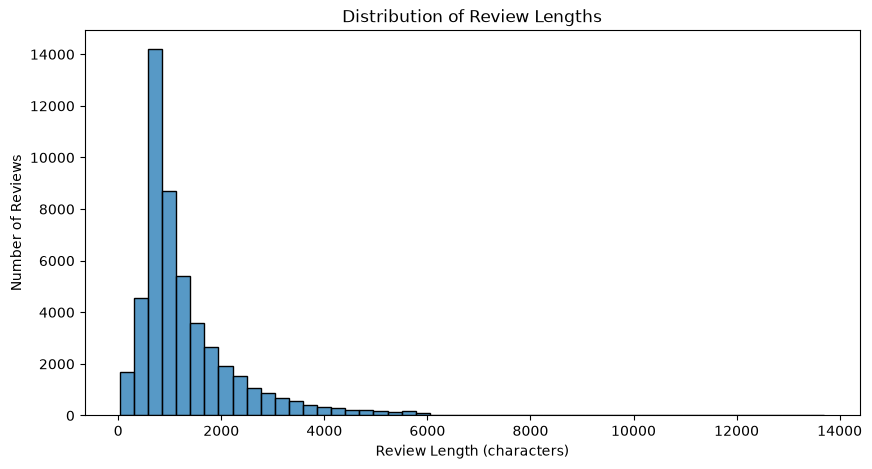

In [50]:
plt.figure(figsize=(10, 5))

sns.histplot(df_clean["text_length"], bins=50)

plt.title("Distribution of Review Lengths")
plt.xlabel("Review Length (characters)")
plt.ylabel("Number of Reviews")

plt.show()

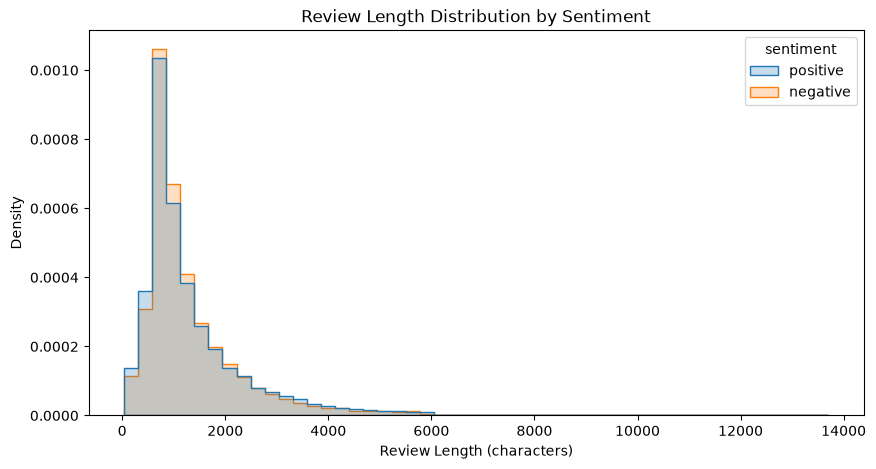

In [51]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df_clean,
    x="text_length",
    hue="sentiment",
    bins=50,
    element="step",
    stat="density",
    common_norm=False
)

plt.title("Review Length Distribution by Sentiment")
plt.xlabel("Review Length (characters)")
plt.ylabel("Density")

plt.show()

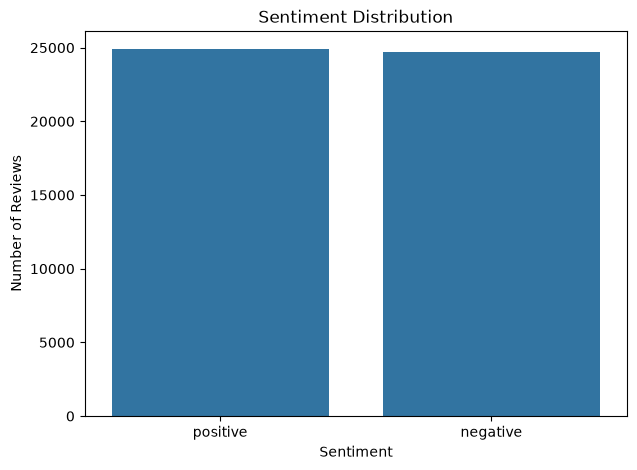

In [52]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df_clean, x="sentiment")

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.show()

In [53]:
import re

In [54]:
def clean_text(text):
    text = re.sub(r"<br\s*/?>", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

In [55]:
df_clean["clean_review"] = df_clean["review"].apply(clean_text)

In [56]:
print("BEFORE:")
print(df_clean.iloc[1]["review"])

print("\nAFTER:")
print(df_clean.iloc[1]["clean_review"])

BEFORE:
A wonderful little production. <br /><br />The filming technique is very unassuming- very old-time-BBC fashion and gives a comforting, and sometimes discomforting, sense of realism to the entire piece. <br /><br />The actors are extremely well chosen- Michael Sheen not only "has got all the polari" but he has all the voices down pat too! You can truly see the seamless editing guided by the references to Williams' diary entries, not only is it well worth the watching but it is a terrificly written and performed piece. A masterful production about one of the great master's of comedy and his life. <br /><br />The realism really comes home with the little things: the fantasy of the guard which, rather than use the traditional 'dream' techniques remains solid then disappears. It plays on our knowledge and our senses, particularly with the scenes concerning Orton and Halliwell and the sets (particularly of their flat with Halliwell's murals decorating every surface) are terribly well

In [57]:
X = df_clean["clean_review"]
y = df_clean["sentiment"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (49582,)
y shape: (49582,)


In [58]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 39665
Testing samples: 9917


In [59]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

In [60]:
baseline_model = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=50000,
        ngram_range=(1, 1)
    )),
    ("classifier", LogisticRegression(max_iter=1000))
])

In [61]:
print("Training baseline model...")

baseline_model.fit(X_train, y_train)

print("Baseline model trained successfully!")

Training baseline model...
Baseline model trained successfully!


In [62]:
y_pred = baseline_model.predict(X_test)

print("Predictions generated successfully!")

Predictions generated successfully!


In [63]:
print("First 10 predictions:")
print(y_pred[:10])

print("\nFirst 10 actual labels:")
print(y_test.iloc[:10].values)

First 10 predictions:
['negative' 'positive' 'positive' 'negative' 'negative' 'positive'
 'negative' 'negative' 'positive' 'negative']

First 10 actual labels:
<StringArray>
['negative', 'positive', 'positive', 'negative', 'negative', 'positive',
 'negative', 'negative', 'positive', 'negative']
Length: 10, dtype: str


In [64]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, pos_label="positive")
recall = recall_score(y_test, y_pred, pos_label="positive")
f1 = f1_score(y_test, y_pred, pos_label="positive")

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Accuracy : 0.8978
Precision: 0.8886
Recall   : 0.9104
F1 Score : 0.8994


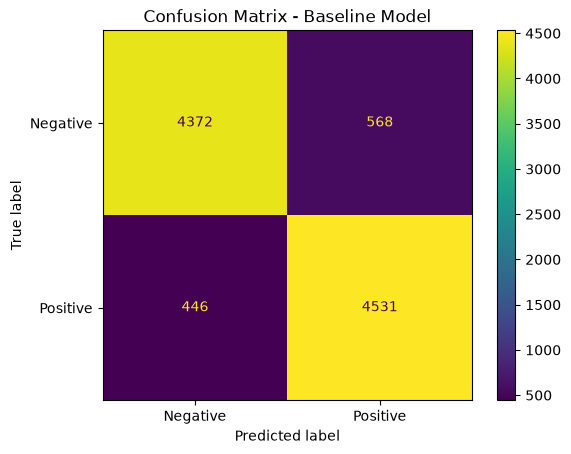

In [65]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=["negative", "positive"]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Negative", "Positive"]
)

disp.plot()
plt.title("Confusion Matrix - Baseline Model")
plt.show()

In [66]:
errors = df_clean.loc[X_test.index].copy()

errors["predicted"] = y_pred
errors = errors[errors["sentiment"] != errors["predicted"]]

print("Total errors:", len(errors))

Total errors: 1014


In [67]:
for _, row in errors.head(5).iterrows():
    print("\n" + "=" * 80)
    print("ACTUAL    :", row["sentiment"])
    print("PREDICTED :", row["predicted"])
    print("REVIEW    :", row["clean_review"])


ACTUAL    : positive
PREDICTED : negative
REVIEW    : This isn't exactly a great film, but I admire the writers and director for trying something a little different. The film's main theme is fate and small, seemingly insignificant things that can greatly change the future. In some ways this reminds me of the film SLIDING DOORS, though instead of focusing on one random event, seemingly random stuff happens repeatedly and each one helps build to the cute conclusion. Plus, an odd bald guy seems to understand all this and he talks about this during one brief scene--like he's some sort of omnipotent being but there's absolutely no explanation of him in the film (like the two guys that fight each other in the clock tower in THE HUDSUCKER PROXY). The DVD jacket shows just Audrey Tautou. This is capitalize on her success in AMELIE, though she is only one of many actors in the film and there is no one starring role. The pace is brisk, the acting fine and the conclusion isn't bad at all. The on

In [68]:
improved_model = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=50000,
        ngram_range=(1, 2)
    )),
    ("classifier", LogisticRegression(max_iter=1000))
])

print("Improved model created successfully!")

Improved model created successfully!


In [69]:
print("Training improved model...")

improved_model.fit(X_train, y_train)

print("Improved model trained successfully!")

Training improved model...
Improved model trained successfully!


In [70]:
y_pred_improved = improved_model.predict(X_test)

print("Improved predictions generated successfully!")

Improved predictions generated successfully!


In [71]:
accuracy_improved = accuracy_score(y_test, y_pred_improved)
precision_improved = precision_score(
    y_test, y_pred_improved, pos_label="positive"
)
recall_improved = recall_score(
    y_test, y_pred_improved, pos_label="positive"
)
f1_improved = f1_score(
    y_test, y_pred_improved, pos_label="positive"
)

print(f"Accuracy : {accuracy_improved:.4f}")
print(f"Precision: {precision_improved:.4f}")
print(f"Recall   : {recall_improved:.4f}")
print(f"F1 Score : {f1_improved:.4f}")

Accuracy : 0.9049
Precision: 0.8956
Recall   : 0.9174
F1 Score : 0.9064


In [72]:
comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
    "Baseline": [accuracy, precision, recall, f1],
    "Improved": [
        accuracy_improved,
        precision_improved,
        recall_improved,
        f1_improved
    ]
})

comparison["Improvement"] = comparison["Improved"] - comparison["Baseline"]

comparison

,Metric,Baseline,Improved,Improvement
0,Accuracy,0.897751,0.904911,0.007159
1,Precision,0.888606,0.895645,0.007040
2,Recall,0.910388,0.917420,0.007032
3,F1 Score,0.899365,0.906402,0.007037


In [73]:
import joblib
import os

os.makedirs("../models", exist_ok=True)

joblib.dump(improved_model, "../models/imdb_sentiment_model.joblib")

print("Final model saved successfully!")

Final model saved successfully!


In [74]:
print(os.path.getsize("../models/imdb_sentiment_model.joblib"), "bytes")

2347668 bytes


In [75]:
new_reviews = [
    "This movie was absolutely fantastic. The acting was brilliant and I loved every minute of it.",
    "This was a terrible movie. The story was boring and the acting was awful.",
    "The movie was okay, but the ending was disappointing."
]

predictions = improved_model.predict(new_reviews)

for review, prediction in zip(new_reviews, predictions):
    print("\nReview:", review)
    print("Prediction:", prediction)


Review: This movie was absolutely fantastic. The acting was brilliant and I loved every minute of it.
Prediction: positive

Review: This was a terrible movie. The story was boring and the acting was awful.
Prediction: negative

Review: The movie was okay, but the ending was disappointing.
Prediction: negative


In [76]:
probabilities = improved_model.predict_proba(new_reviews)

for review, prediction, probability in zip(
    new_reviews,
    predictions,
    probabilities
):
    confidence = max(probability) * 100

    print("\nReview:", review)
    print("Prediction:", prediction)
    print(f"Confidence: {confidence:.2f}%")


Review: This movie was absolutely fantastic. The acting was brilliant and I loved every minute of it.
Prediction: positive
Confidence: 88.17%

Review: This was a terrible movie. The story was boring and the acting was awful.
Prediction: negative
Confidence: 99.78%

Review: The movie was okay, but the ending was disappointing.
Prediction: negative
Confidence: 93.40%


In [78]:
[name for name in globals() if "model" in name.lower() or "pipeline" in name.lower()]

['Pipeline', 'baseline_model', 'improved_model']

In [81]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Predict on the test set
y_pred_improved = improved_model.predict(X_test)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, pos_label="positive")
recall = recall_score(y_test, y_pred, pos_label="positive")
f1 = f1_score(y_test, y_pred, pos_label="positive")

print("Model Evaluation")
print("----------------")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Model Evaluation
----------------
Accuracy : 0.8978
Precision: 0.8886
Recall   : 0.9104
F1 Score : 0.8994

Classification Report:
              precision    recall  f1-score   support

    negative       0.91      0.89      0.90      4940
    positive       0.89      0.91      0.90      4977

    accuracy                           0.90      9917
   macro avg       0.90      0.90      0.90      9917
weighted avg       0.90      0.90      0.90      9917



In [82]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

accuracy_improved = accuracy_score(y_test, y_pred_improved)
precision_improved = precision_score(
    y_test, y_pred_improved, pos_label="positive"
)
recall_improved = recall_score(
    y_test, y_pred_improved, pos_label="positive"
)
f1_improved = f1_score(
    y_test, y_pred_improved, pos_label="positive"
)

print("Improved Model Evaluation")
print("=========================")
print(f"Accuracy : {accuracy_improved:.4f}")
print(f"Precision: {precision_improved:.4f}")
print(f"Recall   : {recall_improved:.4f}")
print(f"F1 Score : {f1_improved:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_improved))

Improved Model Evaluation
Accuracy : 0.9049
Precision: 0.8956
Recall   : 0.9174
F1 Score : 0.9064

Classification Report:
              precision    recall  f1-score   support

    negative       0.91      0.89      0.90      4940
    positive       0.90      0.92      0.91      4977

    accuracy                           0.90      9917
   macro avg       0.91      0.90      0.90      9917
weighted avg       0.91      0.90      0.90      9917



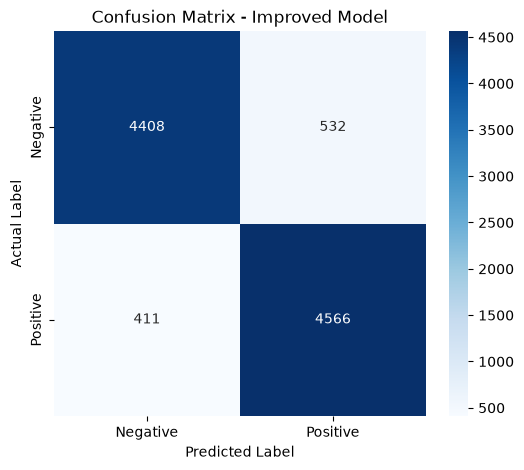

In [83]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_improved, labels=["negative", "positive"])

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - Improved Model")

plt.show()

In [85]:
# Create test DataFrame using the same test indices

df_test = df.loc[X_test.index].copy()

print("Test DataFrame created:", df_test.shape)

Test DataFrame created: (9917, 2)


In [86]:
# Find incorrectly classified reviews

incorrect = y_test != y_pred_improved

errors = df_test.loc[incorrect].copy()

errors["actual"] = y_test[incorrect].values
errors["predicted"] = y_pred_improved[incorrect]

print("Number of incorrect predictions:", len(errors))

errors[["review", "actual", "predicted"]].head(10)

Number of incorrect predictions: 943


,review,actual,predicted
45794,"This isn't exactly a great film, but I admire ...",positive,negative
34722,Despite being a huge fan of Fred Astaire and G...,negative,positive
27228,"Well, well....Roeg touched a bit of a nerve th...",positive,negative
34021,"OK, let me again admit that I haven't seen any...",negative,positive
14432,"I'm not here to tell you ""Armored"" is Kubricki...",positive,negative
12446,"this movie probably had a $750 budget, and sti...",positive,negative
31715,I was excited to hear that someone had made a ...,negative,positive
10346,"Using tons of stock footage, not only from Tra...",negative,positive
15261,"""Saving Grace"" is never riotously funny, but i...",positive,negative
29439,Financially strapped Paramount pulled out all ...,positive,negative


In [87]:
print("Actual Negative → Predicted Positive:", 
      ((errors["actual"] == "negative") & (errors["predicted"] == "positive")).sum())

print("Actual Positive → Predicted Negative:", 
      ((errors["actual"] == "positive") & (errors["predicted"] == "negative")).sum())

Actual Negative → Predicted Positive: 532
Actual Positive → Predicted Negative: 411


In [88]:
import joblib

joblib.dump(improved_model, "../models/imdb_sentiment_model.pkl")

print("Improved model saved successfully!")

Improved model saved successfully!
